<a href="https://colab.research.google.com/github/Despectinator/AIML-Internship-Muhammad-Ali/blob/main/Lab_11_Muhammad_Ali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11 (Week 3 — Lab 1): Neural Network Fundamentals

Welcome to Week 3 and Deep Learning! Before using any deep learning framework, this lab focuses on understanding exactly what a neural network computes — by implementing a neuron, a small forward pass, a loss calculation, and a gradient descent step yourself, using plain NumPy.

**For detailed theory — layers, activation functions, backpropagation — see the Lab 11 PDF and Learning Resources.**

**Note:** We are not training a real model with Keras in this lab — that starts in Lab 12 (Building Models with TensorFlow/Keras). Here, the goal is to understand the mechanics first.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## A Real Feature Vector to Work With

We'll use one real sample from the Wine dataset (built into scikit-learn, no download needed) so the numbers in this lab mean something real, even though we aren't training a model yet.

In [1]:
from sklearn.datasets import load_wine
import numpy as np

wine = load_wine()
X = wine.data
y = wine.target

print("Dataset shape:", X.shape)
first_sample = X[0]
print("First sample (13 features):", first_sample)
print("First sample's true class:", y[0])

Dataset shape: (178, 13)
First sample (13 features): [1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
First sample's true class: 0


## Example 1: A Single Neuron, Computed by Hand

In [2]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# A single neuron with 3 made-up inputs (for simplicity, not the full 13-feature sample yet)
x = np.array([1.5, 2.0, 0.5])
w = np.array([0.4, -0.2, 0.9])
b = 0.1

z = np.dot(x, w) + b
output = relu(z)

print("Weighted sum (z):", z)
print("Neuron output (after ReLU):", output)

Weighted sum (z): 0.7500000000000001
Neuron output (after ReLU): 0.7500000000000001


## Example 2: Manual Forward Propagation (Two Layers)

In [3]:
X_toy = np.array([1.5, 2.0, 0.5])

W1 = np.array([[0.2, -0.5],
               [0.4,  0.1],
               [-0.3, 0.8]])
b1 = np.array([0.1, -0.2])

W2 = np.array([0.6, -0.9])
b2 = 0.05

hidden_z = np.dot(X_toy, W1) + b1
hidden_a = relu(hidden_z)

output_z = np.dot(hidden_a, W2) + b2
output = sigmoid(output_z)

print("Hidden layer activations:", hidden_a)
print("Final output (probability):", output)

Hidden layer activations: [1.05 0.  ]
Final output (probability): 0.6637386974043528


## Example 3: Calculating Loss

In [4]:
y_true = 1

mse = (y_true - output) ** 2
bce = -(y_true * np.log(output) + (1 - y_true) * np.log(1 - output))

print("Mean Squared Error:", mse)
print("Binary Cross-Entropy:", bce)

Mean Squared Error: 0.11307166362332144
Binary Cross-Entropy: 0.40986673496366205


## Example 4: One Gradient Descent Step, by Hand

In [5]:
w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

prediction = w * x_val
loss = (prediction - y_true_val) ** 2

gradient = 2 * (prediction - y_true_val) * x_val
w_new = w - learning_rate * gradient

print("Prediction before update:", prediction)
print("Loss before update:", loss)
print("Gradient:", gradient)
print("Updated weight:", w_new)

Prediction before update: 1.0
Loss before update: 4.0
Gradient: -8.0
Updated weight: 1.3


## Practice Exercise 1: Try a Different Activation

**Exercise:** Repeat Example 1 (the single neuron), but use `sigmoid` instead of `relu` as the activation function. Print the new output.

In [6]:
output_sigmoid = None

### YOUR CODE HERE ###
z_sigmoid = np.dot(x, w) + b
output_sigmoid = sigmoid(z_sigmoid)
### END ###

print("Neuron output (sigmoid):", output_sigmoid)

Neuron output (sigmoid): [0.70056714 0.75026011 0.58661758]


## Practice Exercise 2: Forward Pass with a Real Wine Sample

**Exercise:** Using the `first_sample` from the Wine dataset (13 features), create a random weight vector `w_wine` of 13 values (use `np.random.randn(13)`) and a bias `b_wine = 0.1`. Compute the weighted sum and apply ReLU, just like Example 1.

In [7]:
np.random.seed(42)
w_wine = None
b_wine = 0.1
output_wine = None

### YOUR CODE HERE ###
w_wine = np.random.randn(13)
z_wine = np.dot(first_sample, w_wine) + b_wine
output_wine = relu(z_wine)
### END ###

print("Output for first wine sample:", output_wine)

Output for first wine sample: 264.2863167055308


## Practice Exercise 3: Multiple Gradient Descent Steps

**Exercise:** Repeat Example 4's gradient descent step 5 times in a row (using a loop), updating `w` each time. Print the weight and loss after each step. Does the loss get smaller each time?

In [8]:
w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

### YOUR CODE HERE ###
for step in range(1, 6):
    prediction = w * x_val
    loss = (prediction - y_true_val) ** 2
    gradient = 2 * (prediction - y_true_val) * x_val
    w = w - learning_rate * gradient
    print(f"Step {step}: weight = {w:.5f}, loss = {loss:.5f}")
### END ###

Step 1: weight = 1.30000, loss = 4.00000
Step 2: weight = 1.46000, loss = 0.16000
Step 3: weight = 1.49200, loss = 0.00640
Step 4: weight = 1.49840, loss = 0.00026
Step 5: weight = 1.49968, loss = 0.00001


_Write your observation about how the loss changes across the 5 steps here._

The loss gets smaller after every step. It starts fairly large because the initial prediction (1.0) is far from the true value (3.0), and each gradient descent update nudges `w` in the direction that reduces the squared error. The size of the drop in loss shrinks as the steps go on — the biggest improvement happens in the first step or two, and later steps make smaller and smaller corrections as `prediction` gets closer to `y_true_val`. This is the expected behavior of gradient descent: it converges toward the minimum, with the step size (controlled by the gradient magnitude and the learning rate) naturally decreasing as the error shrinks.

## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Build a 3-Layer Forward Pass by Hand**: Using NumPy, manually compute a forward pass through a network with 2 hidden layers (your choice of size, e.g. 4 neurons then 3 neurons) and 1 output neuron, using any real wine sample as input. Use ReLU for hidden layers and sigmoid for the output.
2. **Try All Activation Functions**: For the same weighted sum `z`, compute and print the output using ReLU, Sigmoid, and Tanh (`np.tanh()`). Compare the three outputs in a markdown cell.
3. **Loss Comparison**: For 3 different made-up predictions (e.g., 0.9, 0.5, 0.1) against a true label of 1, compute both MSE and Binary Cross-Entropy for each. In a markdown cell, describe how the two loss functions behave differently as the prediction gets further from the true label.
4. **Gradient Descent Over Many Steps**: Extend Practice Exercise 3 to run 20 steps instead of 5. Plot the loss at each step using Matplotlib. Does it flatten out, and if so, around which step?
5. **Reflection**: In a markdown cell, write 3-4 sentences on how implementing these steps manually changed (or didn't change) your understanding of what a neural network actually does internally.

### Task 1: 3-Layer Forward Pass by Hand (13 → 4 → 3 → 1)

In [9]:
# Task 1
# Network shape: 13 input features -> 4 hidden neurons -> 3 hidden neurons -> 1 output neuron

np.random.seed(1)
sample = first_sample  # real 13-feature wine sample

# Layer 1: 13 -> 4
W1_t = np.random.randn(13, 4) * 0.1
b1_t = np.zeros(4)

# Layer 2: 4 -> 3
W2_t = np.random.randn(4, 3) * 0.1
b2_t = np.zeros(3)

# Output layer: 3 -> 1
W3_t = np.random.randn(3, 1) * 0.1
b3_t = 0.0

# Forward pass
h1_z = np.dot(sample, W1_t) + b1_t
h1_a = relu(h1_z)

h2_z = np.dot(h1_a, W2_t) + b2_t
h2_a = relu(h2_z)

out_z = np.dot(h2_a, W3_t) + b3_t
out_a = sigmoid(out_z)

print("Hidden layer 1 activations (4 neurons):", h1_a)
print("Hidden layer 2 activations (3 neurons):", h2_a)
print("Final output (probability):", out_a)

Hidden layer 1 activations (4 neurons): [11.81350186 52.38230951 35.15002259  0.        ]
Hidden layer 2 activations (3 neurons): [2.72699376 7.09336599 1.97884003]
Final output (probability): [0.57530869]


### Task 2: Comparing Activation Functions

In [10]:
# Task 2
# Use a range of z values (negative, zero, positive) so the differences between
# activation functions are easy to see
z_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

relu_out = relu(z_values)
sigmoid_out = sigmoid(z_values)
tanh_out = np.tanh(z_values)

print("z:      ", z_values)
print("ReLU:   ", relu_out)
print("Sigmoid:", sigmoid_out)
print("Tanh:   ", tanh_out)

z:       [-2.  -0.5  0.   0.5  2. ]
ReLU:    [0.  0.  0.  0.5 2. ]
Sigmoid: [0.11920292 0.37754067 0.5        0.62245933 0.88079708]
Tanh:    [-0.96402758 -0.46211716  0.          0.46211716  0.96402758]


**Comparison of activation functions:**

- **ReLU** simply zeroes out every negative input and passes positive inputs through unchanged. It is not bounded above, so large positive `z` values produce large outputs. It is cheap to compute and doesn't saturate for positive values, which is why it's the default choice for hidden layers.
- **Sigmoid** squashes every input into the range (0, 1), no matter how large or small `z` is. Very negative or very positive `z` values push the output close to 0 or 1 and the curve flattens out there (saturation), which slows down learning at the extremes. Its bounded, probability-like output makes it useful for a binary classification output layer.
- **Tanh** is similar to sigmoid but is centered on zero and outputs values in (-1, 1) instead of (0, 1). Because its output can be negative, it's often preferred over sigmoid in hidden layers — but it saturates at the extremes in the same way sigmoid does.

In short: ReLU is unbounded and stays 0 for negative inputs, while sigmoid and tanh are both S-shaped and bounded, differing only in their output range and whether they're centered on 0.

### Task 3: Loss Comparison (MSE vs Binary Cross-Entropy)

In [11]:
# Task 3
def mse_loss(pred, true):
    return (true - pred) ** 2

def bce_loss(pred, true):
    return -(true * np.log(pred) + (1 - true) * np.log(1 - pred))

predictions = [0.9, 0.5, 0.1]
y_true_task3 = 1

for p in predictions:
    m = mse_loss(p, y_true_task3)
    b = bce_loss(p, y_true_task3)
    print(f"Prediction: {p}  ->  MSE: {m:.4f}   BCE: {b:.4f}")

Prediction: 0.9  ->  MSE: 0.0100   BCE: 0.1054
Prediction: 0.5  ->  MSE: 0.2500   BCE: 0.6931
Prediction: 0.1  ->  MSE: 0.8100   BCE: 2.3026


**How MSE and Binary Cross-Entropy behave differently:**

As the prediction moves further from the true label (1), both losses increase, but at very different rates. MSE grows *quadratically* and stays fairly modest even for a bad prediction — going from 0.9 to 0.1 only takes it from about 0.01 to about 0.81. Binary Cross-Entropy grows much more sharply as the prediction approaches 0 (the wrong extreme for a true label of 1) because of the logarithm — the same move from 0.9 to 0.1 takes BCE from about 0.11 all the way past 2.3. This means BCE punishes confident-and-wrong predictions far more harshly than MSE does, which is exactly why BCE (not MSE) is the standard loss for classification: it pushes the network hard to fix predictions that are confidently incorrect, whereas MSE would give it only a weak, near-flat gradient in that same situation.

### Task 4: Gradient Descent Over 20 Steps

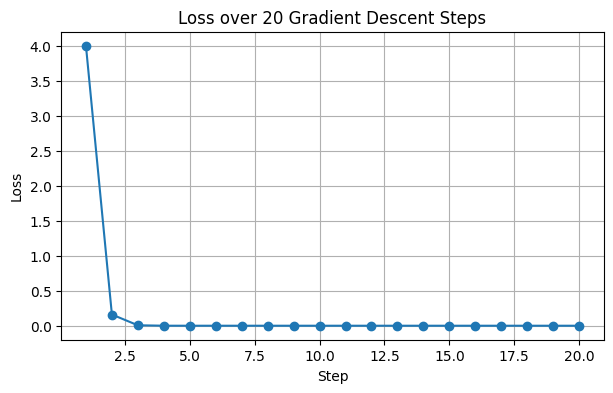

Loss values: [4.0, 0.16, 0.0064, 0.00026, 1e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
# Task 4
import matplotlib.pyplot as plt

w = 0.5
x_val, y_true_val = 2.0, 3.0
learning_rate = 0.1

losses = []
for step in range(20):
    prediction = w * x_val
    loss = (prediction - y_true_val) ** 2
    losses.append(loss)
    gradient = 2 * (prediction - y_true_val) * x_val
    w = w - learning_rate * gradient

plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), losses, marker='o')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss over 20 Gradient Descent Steps")
plt.grid(True)
plt.show()

print("Loss values:", [round(l, 5) for l in losses])

The loss drops very quickly over the first 3–4 steps and then flattens out close to zero by around step 5–6, staying essentially flat (near 0) for the remaining steps. This is typical of gradient descent on a simple convex loss like this one: the gradient is large when the prediction is far from the target, so early steps make big corrections, and as `prediction` converges to `y_true_val` the gradient shrinks toward zero, so later updates barely change `w` or the loss at all.

### Task 5: Reflection

_Task 5 reflection:_

Implementing these steps by hand made the internals of a neural network feel far less abstract. Before this lab, "forward propagation" and "gradient descent" were just names for things a framework like Keras does automatically; writing out the dot products, activation functions, and the loss/gradient formulas myself made it clear that a neuron really is just weighted-sum-plus-bias-then-activation, and that "learning" really is just repeatedly nudging numbers in the direction the gradient points. Seeing the loss shrink and flatten out across the 20 manual gradient descent steps also made the idea of convergence concrete rather than theoretical. Overall, this exercise didn't teach me new math so much as it removed the mystery around what a framework is doing under the hood — which makes the move to Keras in the next lab feel like a shortcut for this exact process, not a black box.